# Task1, Monte carlo


1. ratio of pi analytically, on paper but simply pir^2/1 => pi/4 when r = 1/2

In [147]:
"all tasks related to the monte carlo sim of \pi"
import random

def estimate_pi(num_samples):
    inside_circle = 0
    outside_circle = 0
    #we simply want to draw randum numbers within a unit square, and see how many are within a circle. 
    for _ in range(num_samples):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)

        if x**2 + y**2 <= 1:
            inside_circle += 1
        else:
            outside_circle += 1

    pi = (inside_circle / num_samples) * 4
    X_bar = inside_circle / num_samples       
    
    return pi, X_bar
    

num_samples = 10000
estimated_pi = estimate_pi(num_samples)[0]
estiimated_X_bar = estimate_pi(num_samples)[1]
print(f"Estimated pi: {estimated_pi}")
print(f"Estimated X_bar: {estiimated_X_bar}")


Estimated pi: 3.1644
Estimated X_bar: 0.7925


In [148]:
def biased_estimate_pi(num_samples):
    innside_circle = 0
    outside_circle = 0  

    for _ in range(num_samples):
        x1 = random.uniform(0, 1)
        x2 = x1 + random.uniform(-0.1, 0.1)

        if x1**2 + x2**2 <= 1:
            innside_circle += 1

        else:
            outside_circle += 1


    pi = (innside_circle / num_samples) * 4
    X_bar = innside_circle / num_samples

    return pi, X_bar


num_samples = 10000
biased_pi = biased_estimate_pi(num_samples)[0]
biased_X_bar = biased_estimate_pi(num_samples)[1]
print(f"Est pi:{biased_pi}")
print(f"Est X_bar: {biased_X_bar}")


Est pi:2.8244
Est X_bar: 0.7005


Answer to task 8: both estimates change downwards when redefining x2 as x1 + uniformly drawn noise. The reason for this is because it is now possible to draw values outside of our box, meaning our possible vakue space has increased without out circle increasing. (Noise has inflated the denominator of our fraction, we are now sampling from a bigger box.)

# Monte carlo and Multi Armed Bandits


1() The problem we are solving in MAB is control, as we are sampling(estimating) the predicted reward of an action.

2() I would argue that the expected rewards of arms correspond to an action-value function, as the reward you estimate comes from choosing an arm over the other options(similar to choosing next state to traverse to in the hill problem)

3() As a trajectory is a collection of actions, i would argue that the history of arm pulls in MAB would be corresponding to a trajectory.  

4() The MAB algorithms we studied (epsilon-greedy, UCB) would be related to the MC-control family 

5() MC prediction in MAB would simply be to etsimate the reward from a "fixed policy" meaning only pulling one arm. 

6() The purpose of \epsilon in MABa and in MC-control is to introduce some parameter to force exploration. Epsilon is imply some value one tunes with respect to how much one wants to explore. (In MAB, epsilon is the probability of selecting a random arm, while in MC-simulation epsilon is simply there to ensure a nonzero chance of selecting all actions.)

7() Reduce a standard MC-problem to a MAB-problem? I feel like one could argue that set trajectories could be represented as different arms, where the whole path one takes from start to finish would be equivalent to pulling one arm. This would ofcourse imply way to many arms, and the loss of state/reward/state as it would be accumulated for the whole trajectory. 

# Importance Sampling 

Task 1 


In [149]:
#slot R
ex1 = [0, 5, 10, 20]
px1 = [0.35, 0.30, 0.25, 0.10]

#slot S
ex2 = [0, 5, 10, 20]
px2 = [0.30, 0.35, 0.30, 0.05]

def expected_value(ex, px):
    #once again, zip function matches index for ex1, px1 osv
    expected_val = sum(x * p for x, p in zip(ex, px))
    return expected_val

ev1 = expected_value(ex1, px1)
ev2 = expected_value(ex2, px2)

#will be used as ground thruth for ref. 
print(f"ev1: {ev1}, ev2: {ev2}")

ev1: 6.0, ev2: 5.75


In [150]:
#2, implementing the slot machines
import random

def draw_S():
    ex2 = [0, 5, 10, 20]
    px2 = [0.30, 0.35, 0.30, 0.05]

    return random.choices(ex2, px2)[0]

def draw_R():
    ex1 = [0, 5, 10, 20]
    px1 = [0.35, 0.30, 0.25, 0.10]

    return random.choices(ex1, px1)[0]

p = draw_S()
print(p)

def sample_avg_estimate(num_samples, slot):
    n = 0
    for _ in range(num_samples):
        n+= slot()

    return n / num_samples

num_samples = 10000
estimated_ev = sample_avg_estimate(num_samples, draw_S)
print(f"Estimated expected value: {estimated_ev}")

0
Estimated expected value: 5.8015


In [151]:
#compute ratio \rho

def rho(p1, p2): 
    ratio = []
    for i in range(len(p1)):
            ratio.append(p1[i] / p2[i])
    return ratio

rho(px1, px2)

[1.1666666666666667, 0.8571428571428572, 0.8333333333333334, 2.0]

In [152]:
num_samples = 10000
samples_s = [draw_S() for _ in range(num_samples)]
print(samples_s)    

[5, 0, 5, 5, 10, 5, 0, 0, 10, 5, 0, 5, 5, 0, 0, 0, 5, 0, 10, 0, 5, 5, 10, 10, 0, 5, 10, 10, 10, 0, 5, 5, 0, 5, 10, 0, 5, 5, 10, 5, 10, 5, 10, 10, 5, 5, 20, 10, 5, 0, 5, 0, 0, 0, 10, 0, 5, 10, 0, 5, 5, 0, 0, 5, 20, 0, 5, 10, 5, 5, 0, 0, 10, 10, 10, 10, 10, 5, 5, 10, 0, 10, 10, 5, 10, 10, 10, 0, 5, 10, 0, 5, 5, 10, 10, 5, 10, 10, 10, 0, 10, 5, 5, 5, 0, 5, 10, 0, 0, 20, 10, 10, 0, 10, 10, 10, 0, 5, 10, 20, 5, 10, 5, 0, 10, 10, 5, 5, 20, 10, 5, 20, 5, 5, 0, 5, 0, 0, 5, 20, 5, 0, 0, 5, 5, 0, 10, 0, 10, 10, 0, 10, 5, 0, 10, 0, 20, 10, 10, 5, 0, 20, 5, 5, 0, 5, 0, 10, 5, 5, 5, 0, 5, 10, 5, 0, 5, 5, 0, 10, 5, 20, 0, 10, 5, 10, 0, 0, 10, 0, 0, 0, 20, 0, 10, 10, 10, 0, 5, 10, 10, 5, 0, 0, 0, 0, 10, 10, 0, 10, 10, 5, 5, 5, 0, 10, 0, 0, 10, 5, 0, 5, 0, 10, 10, 5, 5, 10, 5, 10, 10, 10, 20, 0, 0, 10, 0, 0, 10, 10, 10, 5, 0, 0, 10, 10, 10, 0, 5, 10, 10, 10, 20, 0, 10, 5, 5, 10, 10, 5, 20, 5, 5, 5, 5, 0, 5, 10, 20, 5, 10, 10, 5, 10, 10, 5, 5, 10, 10, 10, 10, 10, 0, 0, 0, 0, 0, 0, 5, 5, 5, 0, 0, 10, 5,

In [153]:
#5, samples from S, know \rho, compute E^hat[R]
import numpy as np

# reuse your existing variables/functions:
# ex2, px1, px2, rho(p1, p2), samples_s

rho_vals = rho(px1, px2)                 # [0.35/0.30, 0.30/0.35, 0.25/0.30, 0.10/0.05]
rho_map = dict(zip(ex2, rho_vals))       # {0:..., 5:..., 10:..., 20:...}

# ordinary IS
E_R_hat = sum(rho_map[x] * x for x in samples_s) / len(samples_s)
print("IS estimate of E[R]:", E_R_hat)

# self-normalized IS
w = [rho_map[x] for x in samples_s]
E_R_hat_snis = sum(w_i * x for w_i, x in zip(w, samples_s)) / sum(w)
print("SNIS estimate of E[R]:", E_R_hat_snis)

IS estimate of E[R]: 5.836571428572098
SNIS estimate of E[R]: 5.856987212569983


In [154]:
#6, introducing a new slot machine
num_samples = 10000

ex3 = [0, 5, 10, 20]
px3 = [0.25, 0.25, 0.25, 0.25]

def draw_S2():
    ex3 = [0, 5, 10, 20]
    px3 = [0.25, 0.25, 0.25, 0.25]

    return random.choices(ex3, px3)[0]

samples_s2 = [draw_S2() for _ in range(num_samples)]    

estimated_ev_S2 = sample_avg_estimate(num_samples, draw_S2)
print(f"Estimated expected value for S2: {estimated_ev_S2}")

rho_2 = rho(px1, px3)  # rho_2 is ratio between R and S2
print(f"rho for R vs S2: {rho_2}")   

rho2_map = dict(zip(ex3, rho_2))  # map from outcomes to rho values for S2  

ES2_hat = sum(rho2_map[x] * x for x in samples_s2) / len(samples_s2)  
print("IS estimate of E[R] using S2 samples:", ES2_hat)

Estimated expected value for S2: 8.7445
rho for R vs S2: [1.4, 1.2, 1.0, 0.4]
IS estimate of E[R] using S2 samples: 5.9658


In [155]:
num_samples = 10000

ex4 = ex3
px4 = [0.001, 0.499, 0.499, 0.001]

def draw_S3():
    ex4 = [0, 5, 10, 20]
    px4 = [0.001, 0.499, 0.499, 0.001]

    return random.choices(ex4, px4)[0]

samples_s3 = [draw_S3() for _ in range(num_samples)]

estimated_ev_S3 = sample_avg_estimate(num_samples, draw_S3)
print(f"Estimated expected value for S3: {estimated_ev_S3}")

rho_3 = rho(px1, px4)  # rho_3 is ratio between R and S3    
print(f"rho for R vs S3: {rho_3}")

rho3_map = dict(zip(ex4, rho_3))  # map from outcomes to rho values for S3

ES3_hat = sum(rho3_map[x] * x for x in samples_s3) / len(samples_s3)    
print("IS estimate of E[R] using S3 samples:", ES3_hat)

Estimated expected value for S3: 7.5185
rho for R vs S3: [349.99999999999994, 0.6012024048096192, 0.501002004008016, 100.0]
IS estimate of E[R] using S3 samples: 5.3997995991975385


8() The results ive competed differ due to the different ratios(\rhos) for different outcomes. For the last slot especially, S3(or S'') we get a ratio p with ridicolously large or small values, meaning the scaled value from each sample will either be super small or big, which implies a large variation when estimating the average E[R]. Therefore, even with 10000 simulations, the value for E[R] when estimated with rho(S'', R) fluctuates alot. 

# Q-learning

1() why does one not need to rely on the importance ratio in q-learning? 

We don’t need importance sampling in Q-learning because it does not estimate the value of a target policy’s return from trajectories generated by another policy; instead it uses sampled transitions and applies the Bellman optimality backup which is valid under any behavior policy that provides sufficient exploration. (Think, target is optimal greedy action in a', s', not dep on b in the same way because we are doing "off policy optimality backoffs", not exp sampling".)

## Part 2, coding 

In [156]:
from pathlib import Path
import pickle

#help from codex to load traj from correct path

traj_rel = Path("src/mountain_2/mountain/envs/trajectories.pickle")
traj_path = next((base / traj_rel for base in [Path.cwd(), *Path.cwd().parents] if (base / traj_rel).exists()), None)

if traj_path is None:
    raise FileNotFoundError("Could not find src/mountain_2/mountain/envs/trajectories.pickle")

with open(traj_path, "rb") as f:
    trajectories = pickle.load(f)

print(f"Loaded {len(trajectories)} trajectories from {traj_path}")
print(f"Type of trajectories object: {type(trajectories)}")
print(f"Type of first trajectory: {type(trajectories[0])}, length: {len(trajectories[0])}")
print("First transition (s_t, a_t, r_{t+1}, s_{t+1}):")
print(trajectories[0][0])

Loaded 1000 trajectories from c:\pythonlek\8sem\Reinforcement-Learning-\src\mountain_2\mountain\envs\trajectories.pickle
Type of trajectories object: <class 'list'>
Type of first trajectory: <class 'list'>, length: 169
First transition (s_t, a_t, r_{t+1}, s_{t+1}):
((np.int32(15), np.int32(0)), np.int64(0), np.float64(-0.5706047114070424), (np.int32(15), np.int32(1)))


In [161]:
from collections import defaultdict
import numpy as np

gamma = 1.0  # same idea as last time, only care about total time spent to get down from the mountain, proxied by the roughness index.

#functions to help "navigate" the data in trajectories
def to_state_key(s):
    return tuple(int(x) for x in s) if isinstance(s, (tuple, list, np.ndarray)) else int(s)

def to_action_key(a):
    return int(a)

def MC_stat_value(trajectories, gamma=1.0):
    """First-visit MC estimate of v_pi(s). Returns a dictionary keyed by state."""
    state_return_sum = defaultdict(float)
    state_return_count = defaultdict(int)

    #episode here is simply a trajectory, with trajectories being a collection of trajectories. Each trajectory is a list of transitions (s_t, a_t, r_{t+1}, s_{t+1})
    for episode in trajectories:
        G = 0.0
        returns_from_t = [0.0] * len(episode)

        # Backward return computation
        for t in range(len(episode) - 1, -1, -1):
            _, _, r_t1, _ = episode[t]
            G = float(r_t1) + gamma * G
            returns_from_t[t] = G

        seen_states = set()
        for t, (s_t, _, _, _) in enumerate(episode):
            s = to_state_key(s_t)
            if s not in seen_states:
                seen_states.add(s)
                state_return_sum[s] += returns_from_t[t]
                state_return_count[s] += 1

    v_pi = {s: state_return_sum[s] / state_return_count[s] for s in state_return_sum}  # averaging returns over all states 
    return v_pi

def MC_action_value(trajectories, gamma=1.0):
    """First-visit MC estimate of q_pi(s,a). Returns a dictionary keyed by (state, action)."""
    state_action_return_sum = defaultdict(float)
    state_action_return_count = defaultdict(int)

    for episode in trajectories:
        G = 0.0
        returns_from_t = [0.0] * len(episode)

        # Backward return computation
        for t in range(len(episode) - 1, -1, -1):
            _, _, r_t1, _ = episode[t]
            G = float(r_t1) + gamma * G
            returns_from_t[t] = G

        seen_state_actions = set()
        for t, (s_t, a_t, _, _) in enumerate(episode):
            s = to_state_key(s_t)
            a = to_action_key(a_t)
            sa = (s, a)
            if sa not in seen_state_actions:
                seen_state_actions.add(sa)
                state_action_return_sum[sa] += returns_from_t[t]
                state_action_return_count[sa] += 1

    q_pi = {sa: state_action_return_sum[sa] / state_action_return_count[sa] for sa in state_action_return_sum}
    return q_pi

v_pi = MC_stat_value(trajectories, gamma=gamma)
q_pi = MC_action_value(trajectories, gamma=gamma)

print(f"Estimated v_pi for {len(v_pi)} states")
print(f"Estimated q_pi for {len(q_pi)} state-action pairs")

Estimated v_pi for 2924 states
Estimated q_pi for 14138 state-action pairs


Task 3, plot 

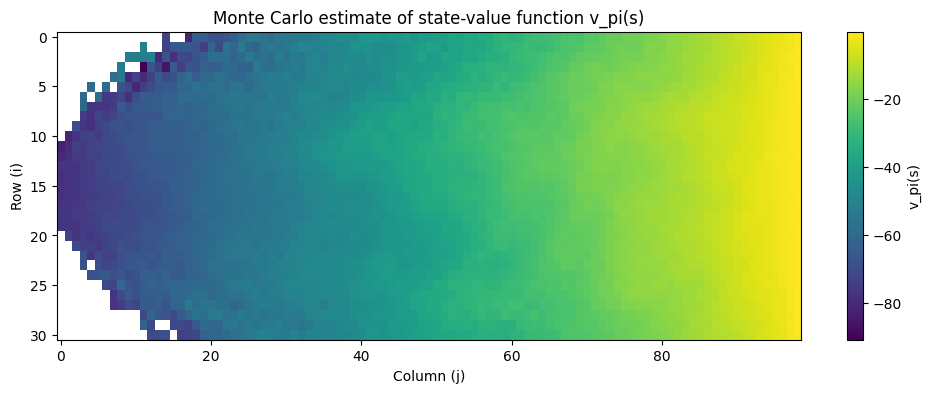

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# infer grid size from visited states
max_i = max(s[0] for s in v_pi.keys())
max_j = max(s[1] for s in v_pi.keys())

value_grid = np.full((max_i + 1, max_j + 1), np.nan)

for (i, j), val in v_pi.items():
    value_grid[i, j] = val

plt.figure(figsize=(12, 4))
im = plt.imshow(value_grid, aspect="auto", origin="upper", cmap="viridis")
plt.colorbar(im, label="v_pi(s)")
plt.title("Monte Carlo estimate of state-value function v_pi(s)")
plt.xlabel("Column (j)")
plt.ylabel("Row (i)")
plt.show()

## task 4, mc improvement

In [ ]:
from collections import defaultdict

#whole clue with mc-improvement, as we remember from lecture is that we can select an action that maximizes q_pi(s,a) for each state s to get an improved policy.
def MC_improvement_from_q(q_pi):
    q_by_state = defaultdict(dict)
    for (state, action), q_val in q_pi.items():
        q_by_state[state][action] = q_val

    improved_policy = {}
    for state, action_values in q_by_state.items():
        best_action = max(action_values, key=action_values.get)
        improved_policy[state] = best_action
    return improved_policy, q_by_state

improved_policy, q_by_state = MC_improvement_from_q(q_pi)
print("States with improved action:", len(improved_policy))
print("Example:", list(improved_policy.items())[:10])

States with improved action: 2924
Example: [((15, 0), 2), ((15, 1), 4), ((16, 1), 2), ((17, 1), 4), ((16, 2), 3), ((15, 3), 4), ((16, 4), 2), ((16, 5), 0), ((17, 5), 1), ((16, 6), 0)]


## task 5, results 

my first thoughts here is that for eval, you would want as many trajectories as possible to get good estimates for the true values of each state from simulation, with the only real caveat being that similar very similar trajectories would be less worth than more unique ones? for impprovement, as one is trying to find better policies(actions), i would guess the trajectories with higher reward holds more value compared to poor trajectories. 

additional comment after some extra reflection: number of state-action pairs visited in a trajectory also matters, as longer more infromative trajectories are more valuable than a shorter repetetive one.

Comment on the results: notice that mc-improvement apparently "improved" action for all estimated states. also noticed that the ratio of action_values compared to state values roughly equals 5, meaning we evaluate ca. 5 actions for each state. 

## task 6, MC control

at this point in the hw, we have no simulator for M, only trajectories, which are not sufficient for implementing MC-control

## task 7, env mountain(1) + starting policy + mc-control (task 8)

In [8]:
import mountain
import gymnasium 

#env = gymnasium.make('mountain/GridWorld-v0') //  tried with code as in the read-me, but version v0 was depriciated?? 

In [9]:
import mountain
import gymnasium

env_v1 = gymnasium.make('mountain/GridWorld-v1')
print(env_v1)
print("Action space:", env_v1.action_space)      # Discrete(5)
print("Observation space:", env_v1.observation_space)


<OrderEnforcing<PassiveEnvChecker<MountainEnv<mountain/GridWorld-v1>>>>
Action space: Discrete(5)
Observation space: Dict('agent': Dict('pos': Box(0, [99 30], (2,), int32)))


In [ ]:
import numpy as np
from collections import defaultdict

N_ACTIONS = 5
FORWARD_ACTIONS = [0, 2, 4]
OTHER_ACTIONS   = [1, 3]

#want to define functions for starting policy and episode_gen before defining mc_control algo. 

def starting_policy(state):
    #idea here for stating policy is simply that i want to favour forward actions, as i wont to get down the mountain. 
    probs = np.zeros(N_ACTIONS)
    probs[FORWARD_ACTIONS] = 0.9 / len(FORWARD_ACTIONS)  # 0.30 each
    probs[OTHER_ACTIONS]   = 0.1 / len(OTHER_ACTIONS)    # 0.05 each
    return probs


#function for episode gen
def generate_episode(env, policy):
    obs, _ = env.reset()
    state = tuple(obs["agent"]["pos"])
    episode = []

    while True:
        probs = policy(state)
        action = np.random.choice(N_ACTIONS, p=probs)
        obs, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = tuple(obs["agent"]["pos"])
        if terminated or truncated:
            break

    return episode

def mc_control(env, n_episodes=50_000, gamma=1.0, epsilon=0.1, tol=1e-4, patience=200):
    Q = defaultdict(lambda: np.zeros(N_ACTIONS))
    N = defaultdict(lambda: np.zeros(N_ACTIONS))
    policy = starting_policy
    stable = 0
    ep_returns = []   # <-- add

    for ep in range(n_episodes):
        episode = generate_episode(env, policy)
        ep_returns.append(sum(r for _, _, r in episode))   # <-- add

        G = 0.0
        visited = set()
        max_delta = 0.0

        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                N[state][action] += 1
                old = Q[state][action]
                Q[state][action] += (G - old) / N[state][action]
                max_delta = max(max_delta, abs(Q[state][action] - old))

        def policy(s, _Q=Q):
            probs = np.ones(N_ACTIONS) * epsilon / N_ACTIONS
            probs[np.argmax(_Q[s])] += 1.0 - epsilon
            return probs

        stable = stable + 1 if max_delta < tol else 0
        if stable >= patience:
            print(f"Converged at episode {ep+1} (max_delta={max_delta:.2e})")
            break

    def greedy_policy(s):
        probs = np.zeros(N_ACTIONS)
        probs[np.argmax(Q[s])] = 1.0
        return probs

    return Q, greedy_policy, np.array(ep_returns)   # <-- changed

#had to reimplement the algo with a list for returns s.t. the later comparison task would be doable. 
Q, learned_policy, ep_returns = mc_control(env_v1)

Learned Q-values for some states:


In [ ]:
#for the mountain 2 env 

env_2 = gymnasium.make('mountain/GridWorld-v2')

N_ACTIONS = 8
FORWARD_ACTIONS = [0, 2, 4]
OTHER_ACTIONS   = [1, 3, 5, 6, 7]

"""reusing existing implementation with expanded action space, same idea for stating policy as it is defined to handle
the expanded action space"""

Q_v2, optimal_policy_v2 = mc_control(env_2, n_episodes=50_000) 

c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


next sesh, implement some function to check convergence to answer q10..

## task 11 ++ (temporal difference algos )

### implementing sarsa(0)


for sarsa read : https://www.datacamp.com/tutorial/sarsa-reinforcement-learning-algorithm-in-python?dc_referrer=https%3A%2F%2Fwww.google.com%2F

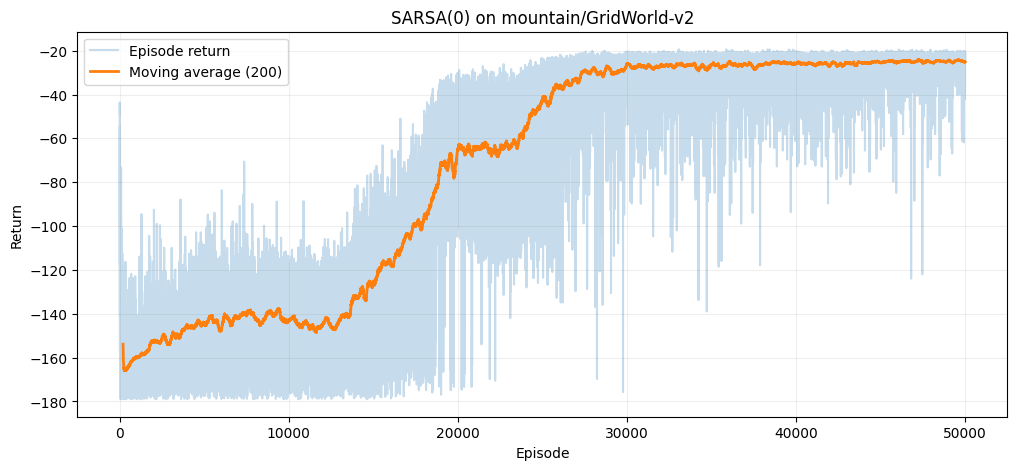

In [ ]:
# implementation for sarsa(0) with stored ep returns for later tasks about eval/plots 
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def train_sarsa_with_history(env, n_episodes=10_000, gamma=1.0, alpha=0.1, epsilon=0.1):
    n_actions = env.action_space.n
    Q_hist = defaultdict(lambda: np.zeros(n_actions))
    episode_returns = []

    def eps_greedy_action_local(Q, state, eps):
        if np.random.rand() < eps:
            return np.random.randint(n_actions)
        return int(np.argmax(Q[state]))

    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs["agent"]["pos"])
        action = eps_greedy_action_local(Q_hist, state, epsilon)
        total_reward = 0.0

        while True:
            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = tuple(obs["agent"]["pos"])
            done = terminated or truncated
            total_reward += reward

            if done:
                td_target = reward
            else:
                next_action = eps_greedy_action_local(Q_hist, next_state, epsilon)
                td_target = reward + gamma * Q_hist[next_state][next_action]

            Q_hist[state][action] += alpha * (td_target - Q_hist[state][action])

            if done:
                break

            state, action = next_state, next_action

        episode_returns.append(total_reward)

    return Q_hist, np.array(episode_returns)

# train a fresh SARSA(0) run for plotting
Q_sarsa_plot, sarsa_returns = train_sarsa_with_history(env_2, n_episodes=50000, alpha=0.1, epsilon=0.1)

# moving average
window = 200
kernel = np.ones(window) / window
sarsa_ma = np.convolve(sarsa_returns, kernel, mode="valid")

plt.figure(figsize=(12, 5))
plt.plot(sarsa_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window - 1, len(sarsa_returns)), sarsa_ma, linewidth=2, label=f"Moving average ({window})")
plt.title("SARSA(0) on mountain/GridWorld-v2")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [44]:
#eval in sepearte cell to avoid rerunning the whole algo 

### 12, eval in terms of ? had to rewrite MC-algo to be able to plot returns/ep 

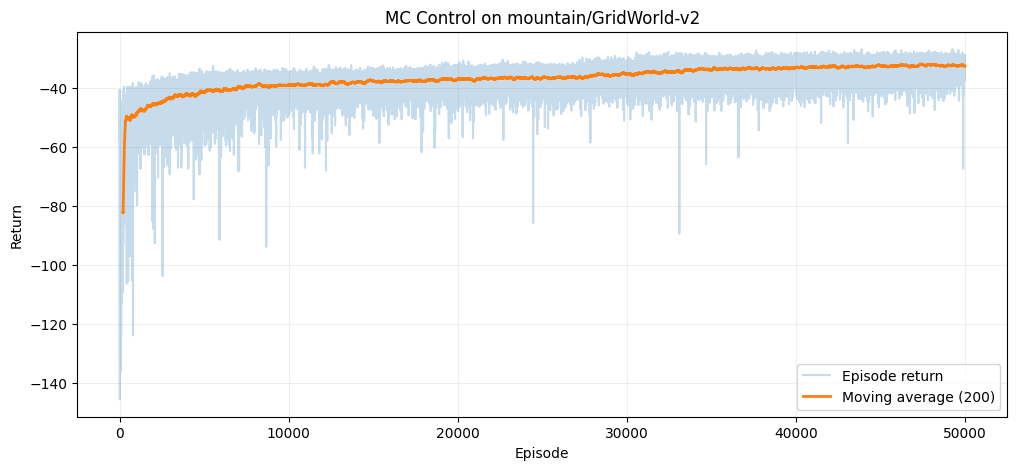

In [61]:
Q_v2, optimal_policy_v2, mc_returns = mc_control(env_2, n_episodes=50000)

window = 200
mc_ma = np.convolve(mc_returns, np.ones(window)/window, mode="valid")

plt.figure(figsize=(12,5))
plt.plot(mc_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window-1, len(mc_returns)), mc_ma, linewidth=2, label=f"Moving average ({window})")
plt.title("MC Control on mountain/GridWorld-v2")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### sarsa(n)

In [59]:
from collections import defaultdict
import numpy as np

def epsilon_greedy_action(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))

def sarsa_n(env, n=4, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1):
    #init 
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    ep_returns = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        start_state = tuple(obs["agent"]["pos"])
        start_action = epsilon_greedy_action(Q, start_state, epsilon, n_actions)
        episode_return = 0.0

        #Buffers for one episode trajectory:
        #states[k] = S_k, actions[k] = A_k, rewards[k] = R_k (with rewards[1] = first real reward)
        states = [start_state]
        actions = [start_action]
        rewards = [0.0]  #dummy so indexing matches RL notation (R_{t+1})

        T = np.inf  #terminal time step (unknown until episode ends)
        t = 0

        while True:
            # 1)Interact with environment while episode not ended
            if t < T:
                obs, reward, terminated, truncated, _ = env.step(actions[t])
                rewards.append(reward)                         #stores R_{t+1}
                episode_return += reward
                next_state = tuple(obs["agent"]["pos"])
                states.append(next_state)                      #stores S_{t+1}

                if terminated or truncated:
                    T = t + 1                                  #episode ends at time T
                else:
                    next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
                    actions.append(next_action)                #stores A_{t+1}

            # 2)Decide which earlier time index can be updated now
            #tau is the state-action index whose n-step target is now available (fully or partially)
            tau = t - n + 1

            if tau >= 0:
                # 3)Build the n-step target G for (S_tau, A_tau)
                #General form:
                #G = R_{tau+1} + gamma*R_{tau+2} + ... + gamma^{n-1}*R_{tau+n}
                #    + gamma^n * Q(S_{tau+n}, A_{tau+n})   [only if tau+n < T]

                if np.isinf(T):
                    upper = tau + n
                else:
                    upper = min(tau + n, int(T))

                #Reward-only part:
                #sum_{i=tau+1}^{upper} gamma^{i-tau-1} * R_i
                G = 0.0
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]

                #Bootstrap part if we have not hit terminal before tau+n
                #(i.e., still have an action A_{tau+n} to bootstrap from)
                if tau + n < T:
                    G += (gamma ** n) * Q[states[tau + n]][actions[tau + n]]

                #4) Update Q at the delayed index tau
                state_tau, action_tau = states[tau], actions[tau]
                Q[state_tau][action_tau] += alpha * (G - Q[state_tau][action_tau])

            #5) Stop when the final eligible tau (T-1) has been updated
            if tau == T - 1:
                break

            t += 1

        ep_returns.append(episode_return)

    return Q, np.array(ep_returns)

Q_sarsa4, sarsa4_returns = sarsa_n(env_2, n=4, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1)
Q_sarsa3, sarsa3_returns = sarsa_n(env_2, n=3, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1)
Q_sarsa5, sarsa5_returns = sarsa_n(env_2, n=5, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1)

### 14, comparing avg return/ep for sarsa(n), sarsa(0)

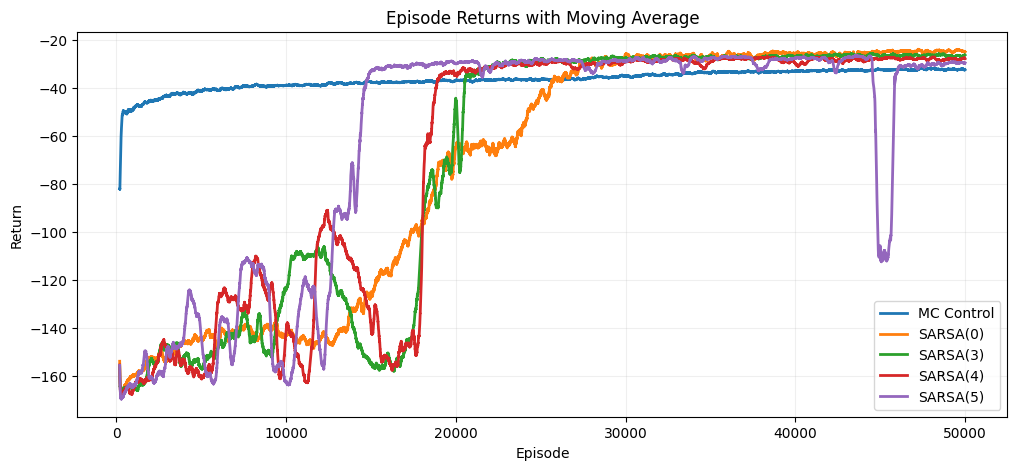

In [62]:
def plot_returns(*args, labels=None, window=200):
    plt.figure(figsize=(12, 5))
    for i, returns in enumerate(args):
        ma = np.convolve(returns, np.ones(window)/window, mode="valid")
        label = labels[i] if labels else f"Returns {i+1}"
        plt.plot(np.arange(window-1, len(returns)), ma, linewidth=2, label=label)
    plt.title("Episode Returns with Moving Average")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_returns(mc_returns, sarsa_returns, sarsa3_returns, sarsa4_returns, sarsa5_returns, labels=["MC Control", "SARSA(0)", "SARSA(3)", "SARSA(4)", "SARSA(5)"])  


takeaway here, seems mc converges much faster but sarsa achives better returns/episode. Sarsa for larger n unstable? ex fluctuation for sarsa(5)

### 15, q-learning + 16, eval comparison in terms of returns/ep -- proxy for loss, convergence with ma to simplify trend 

In [ ]:
# Q-learning (task 15) + comparison metric (task 16)

def q_learning(env, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1):
    n_actions = env.action_space.n
    Q_q = defaultdict(lambda: np.zeros(n_actions))
    ep_returns_q = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs["agent"]["pos"])
        done = False
        episode_return = 0.0

        #implementation of greedy action selection inside the loop, compared to a defined function as prev. 
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = int(np.argmax(Q_q[state]))

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = tuple(obs["agent"]["pos"])
            done = terminated or truncated
            episode_return += reward

            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q_q[next_state])

            Q_q[state][action] += alpha * (target - Q_q[state][action])
            state = next_state

        ep_returns_q.append(episode_return)

    return Q_q, np.array(ep_returns_q)

Q_q, q_returns = q_learning(env_2, n_episodes=50_000, gamma=1.0, alpha=0.05, epsilon=0.1)

# Metric for comparison: moving-average episode return + final-window average return
window = 200
plot_returns(
    mc_returns,
    sarsa_returns,
    sarsa3_returns,
    sarsa4_returns,
    sarsa5_returns,
    q_returns,
    labels=["MC Control", "SARSA(0)", "SARSA(3)", "SARSA(4)", "SARSA(5)", "Q-learning"],
    window=window,
)

# Numeric summary from same metric family (higher/less-negative is better)
def final_window_mean(returns, w=1000):
    w = min(w, len(returns))
    return float(np.mean(returns[-w:]))

print("Final-window mean return (last 1000 episodes):")
print(f"MC Control : {final_window_mean(mc_returns):.3f}")
print(f"SARSA(0)   : {final_window_mean(sarsa_returns):.3f}")
print(f"SARSA(3)   : {final_window_mean(sarsa3_returns):.3f}")
print(f"SARSA(4)   : {final_window_mean(sarsa4_returns):.3f}")
print(f"SARSA(5)   : {final_window_mean(sarsa5_returns):.3f}")
print(f"Q-learning : {final_window_mean(q_returns):.3f}")
